<a href="https://colab.research.google.com/github/chavezgranados/Quantitative-Methods/blob/main/notebooks/cuaderno10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<font face="gotham" color="#1B5E20"> Unidad de Posgrado de la Facultad de Economía </font>

<img src="https://yachay.digital/wp-content/uploads/2021/03/uncp.png" width="120">

<font face="gotham" color="#1B5E20"> **Curso: Métodos Cuantitativos Aplicados a la Investigación** </font>

<hr width="50%" color="#C9A227">

<font face="gotham" color="#1B5E20"> Maestría en Planificación y Proyectos de Inversión </font>

<font face="gotham" color="#1B5E20"> `Luis Chávez` </font>

<font face="gotham" color="#1B5E20"> 2026 </font>

# <font face="gotham" color="#E3B10D"> **Tópico: probabilidad e inferencia estadística**

**Contenido:**

| # | Tema |
|---|------|
| 1 | Fundamentos: eventos y probabilidad |
| 2 | Variables aleatorias: discretas, continuas y distribuciones conocidas |
| 3 | Distribuciones muestrales |
| 4 | Estimación: puntual e intervalos de confianza |
| 5 | Pruebas de hipótesis |

> 💡 No olvides interpretar correctamente cada resultado.


In [ ]:
# Preámbulo ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import itertools
from math import comb

## **1. Fundamentos**

### **1.1 Eventos**

Un **experimento aleatorio** es un proceso cuyo resultado no se puede predecir con certeza. El **espacio muestral** $\Omega$ es el conjunto de todos los resultados posibles, y un **evento** es cualquier subconjunto de $\Omega$.


> **Ejemplo 1**

In [ ]:
preferencias = ("C", "E")  # C = Conservación del agua, E = Explotación minera
omega = list(itertools.product(preferencias, repeat=3))
omega

[('C', 'C', 'C'),
 ('C', 'C', 'E'),
 ('C', 'E', 'C'),
 ('C', 'E', 'E'),
 ('E', 'C', 'C'),
 ('E', 'C', 'E'),
 ('E', 'E', 'C'),
 ('E', 'E', 'E')]

In [ ]:
A = {r for r in omega if r.count("C") == 3}            # los 3 prefieren conservación
B = {r for r in omega if r.count("E") == 3}            # los 3 prefieren explotación
C = {r for r in omega if r.count("C") >= 2}        # mayoría prefiere conservación
D = {r for r in omega if len(set(r)) == 2}             # hay opiniones divididas (no unanimidad)

eventos = {
    "A: Los 3 prefieren conservación":        A,
    "B: Los 3 prefieren explotación":         B,
    "C: Al menos 2 prefieren conservación":   C,
    "D: Hay opiniones divididas":             D,}
for nombre, evento in eventos.items():
    print(f"{nombre}\n  → {sorted(evento)}\n  → n({len(evento)}) de {len(omega)}\n")

A: Los 3 prefieren conservación
  → [('C', 'C', 'C')]
  → n(1) de 8

B: Los 3 prefieren explotación
  → [('E', 'E', 'E')]
  → n(1) de 8

C: Al menos 2 prefieren conservación
  → [('C', 'C', 'C'), ('C', 'C', 'E'), ('C', 'E', 'C'), ('E', 'C', 'C')]
  → n(4) de 8

D: Hay opiniones divididas
  → [('C', 'C', 'E'), ('C', 'E', 'C'), ('C', 'E', 'E'), ('E', 'C', 'C'), ('E', 'C', 'E'), ('E', 'E', 'C')]
  → n(6) de 8




> **Ejemplo 2**

In [ ]:
Omega = {"P1", "P2", "P3", "P4", "P5", "P6"}
A = {"P1", "P3", "P5"}     # proyectos de saneamiento
B = {"P2", "P3", "P6"}     # proyectos con inversión > S/ 1'000,000
A_c= Omega - A
union = A | B
interseccion = A & B
n = 6   # total de proyectos
k = 2   # proyectos a seleccionar

print("a) A':", A_c)
print("b) A ∪ B:", union)
print("c) A ∩ B:", interseccion)
print("d) Formas de seleccionar 2 proyectos de 6:", comb(n, k))

a) A': {'P4', 'P2', 'P6'}
b) A ∪ B: {'P1', 'P3', 'P2', 'P6', 'P5'}
c) A ∩ B: {'P3'}
d) Formas de seleccionar 2 proyectos de 6: 15



### **1.2 Probabilidad**

La probabilidad clásica (regla de Laplace) de un evento $A$ se define como:

$$P(A) = \frac{\#\text{casos favorables}}{\#\text{casos totales}}$$

**Axiomas de Kolmogórov:**

1. $P(A) \ge 0$ para todo evento $A$.
2. $P(\Omega) = 1$.
3. Si $A$ y $B$ son mutuamente excluyentes, $P(A \cup B) = P(A) + P(B)$.

La **Ley de los Grandes Números (LGN)** dice que, al repetir un experimento muchas veces, la frecuencia relativa de un evento se aproxima a su probabilidad teórica. Lo comprobamos simulando lanzamientos de un dado:


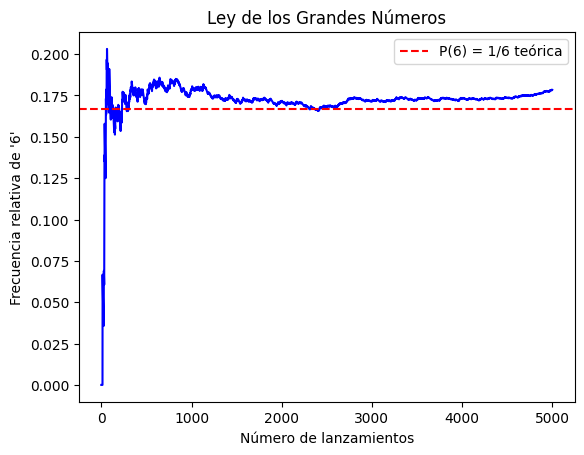

In [ ]:
# LGN: frecuencia relativa de obtener un "6"
n_max = 5000
lanzamientos = np.random.randint(1, 7, size=n_max)
frecuencia_relativa = np.cumsum(lanzamientos == 6) / np.arange(1, n_max + 1)

plt.plot(frecuencia_relativa, color="blue", lw=1.5)
plt.axhline(1/6, color="red", linestyle="--", label="P(6) = 1/6 teórica")
plt.xlabel("Número de lanzamientos")
plt.ylabel("Frecuencia relativa de '6'")
plt.title("Ley de los Grandes Números")
plt.legend()
plt.grid(False)
plt.show()


## **2. Variables aleatorias**

### **2.1 Variables discretas y continuas**

- **Variable aleatoria discreta**: toma un número finito o numerable de valores (ej. número de clientes que llegan a una tienda). Se describe con una **función de probabilidad** (PMF), $P(X=x)$.
- **Variable aleatoria continua**: toma cualquier valor dentro de un intervalo (ej. tiempo de espera, estatura). Se describe con una **función de densidad** (PDF), $f(x)$, donde $P(a \le X \le b) = \int_a^b f(x)\,dx$.

Comparemos ambos casos:

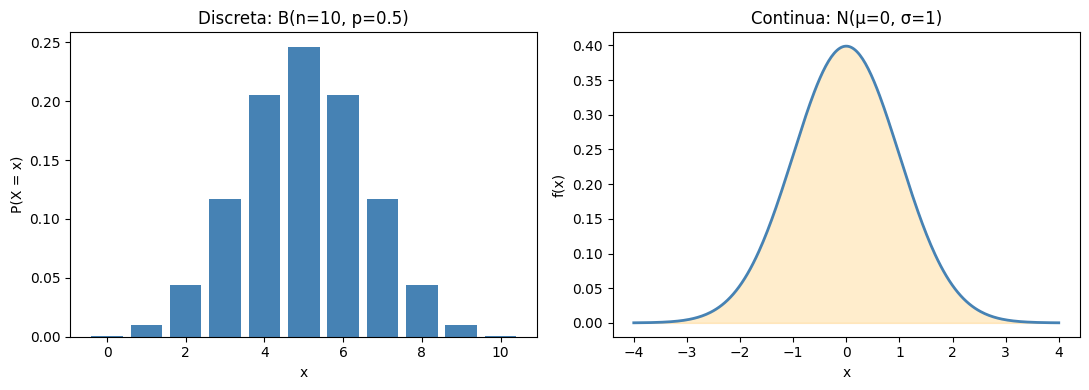

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Discreta: Binomial(n=10, p=0.5)
x_disc = np.arange(0, 11)
pmf = stats.binom.pmf(x_disc, n=10, p=0.5)
axes[0].bar(x_disc, pmf, color="steelblue")
axes[0].set_title("Discreta: B(n=10, p=0.5)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("P(X = x)")
axes[0].grid(False)

# Continua: Normal(mu=0, sigma=1)
x_cont = np.linspace(-4, 4, 300)
pdf = stats.norm.pdf(x_cont, loc=0, scale=1)
axes[1].plot(x_cont, pdf, color="steelblue", lw=2)
axes[1].fill_between(x_cont, pdf, alpha=0.2, color="orange")
axes[1].set_title("Continua: N(μ=0, σ=1)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)")
axes[1].grid(False)
plt.tight_layout()
plt.show()


### **2.2 Distribuciones conocidas**

| Distribución | Tipo | Parámetros | Uso típico |
|---|---|---|---|
| Bernoulli | Discreta | $n$ | Éxito/fracaso |
| Binomial | Discreta | $n, p$ | Éxito/fracaso repetido |
| Poisson | Discreta | $\lambda$ | Conteo de eventos raros en un intervalo |
| Uniforme | Continua | $a, b$ | Igual probabilidad en un rango |
| Normal | Continua | $\mu, \sigma$ | Fenómenos naturales, promedios |
| Exponencial | Continua | $\lambda$ | Tiempos de espera entre eventos |


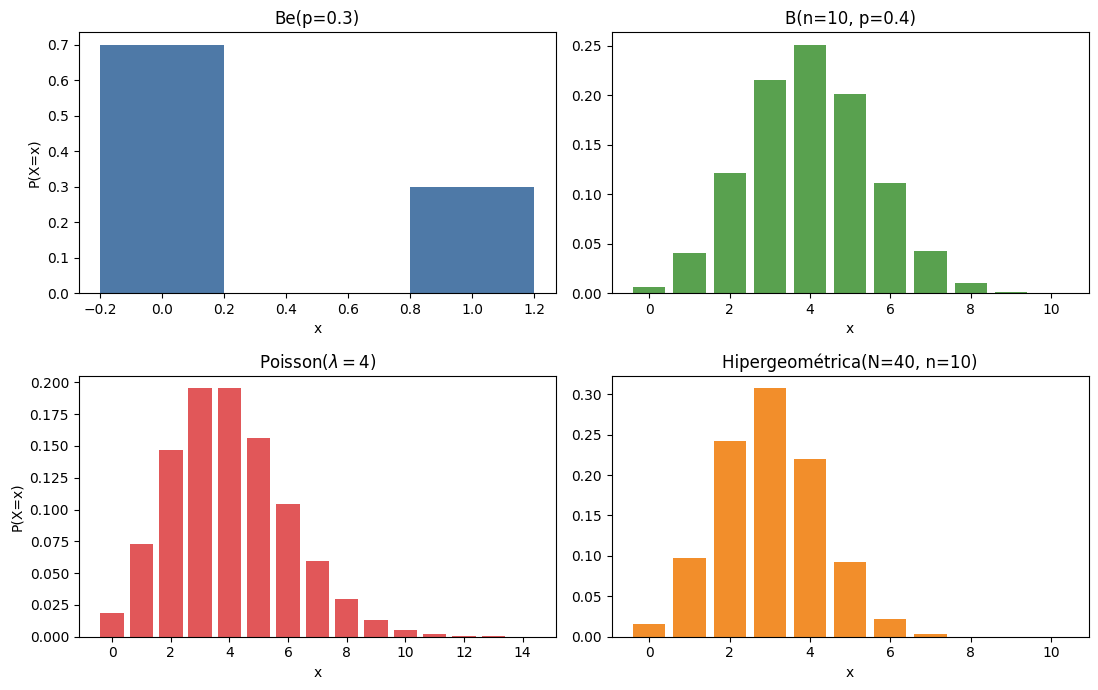

In [ ]:
# ==============================================================================
# Función masa de probabilidad (PMF)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Bernoulli
x = np.array([0, 1])
pmf = stats.bernoulli.pmf(x, p=0.3)
axes[0,0].bar(x, pmf, color="#4E79A7", width=0.4)
axes[0,0].set_title("Be(p=0.3)")
axes[0,0].set_ylabel("P(X=x)")

# Binomial
x = np.arange(0, 11)
pmf = stats.binom.pmf(x, n=10, p=0.4)
axes[0,1].bar(x, pmf, color="#59A14F")
axes[0,1].set_title("B(n=10, p=0.4)")

# Poisson
x = np.arange(0, 15)
pmf = stats.poisson.pmf(x, mu=4)
axes[1,0].bar(x, pmf, color="#E15759")
axes[1,0].set_title("Poisson($\\lambda=4$)")
axes[1,0].set_ylabel("P(X=x)")

# Hipergeométrica
N = 40   # población
K = 12   # éxitos
n = 10   # muestra
x = np.arange(max(0, n-(N-K)), min(n, K)+1)
pmf = stats.hypergeom.pmf(x, M=N, n=K, N=n)
axes[1,1].bar(x, pmf, color="#F28E2B")
axes[1,1].set_title("Hipergeométrica(N=40, n=10)")

for ax in axes.flat:
    ax.set_xlabel("x")
    ax.grid(False)

plt.tight_layout()
plt.show()

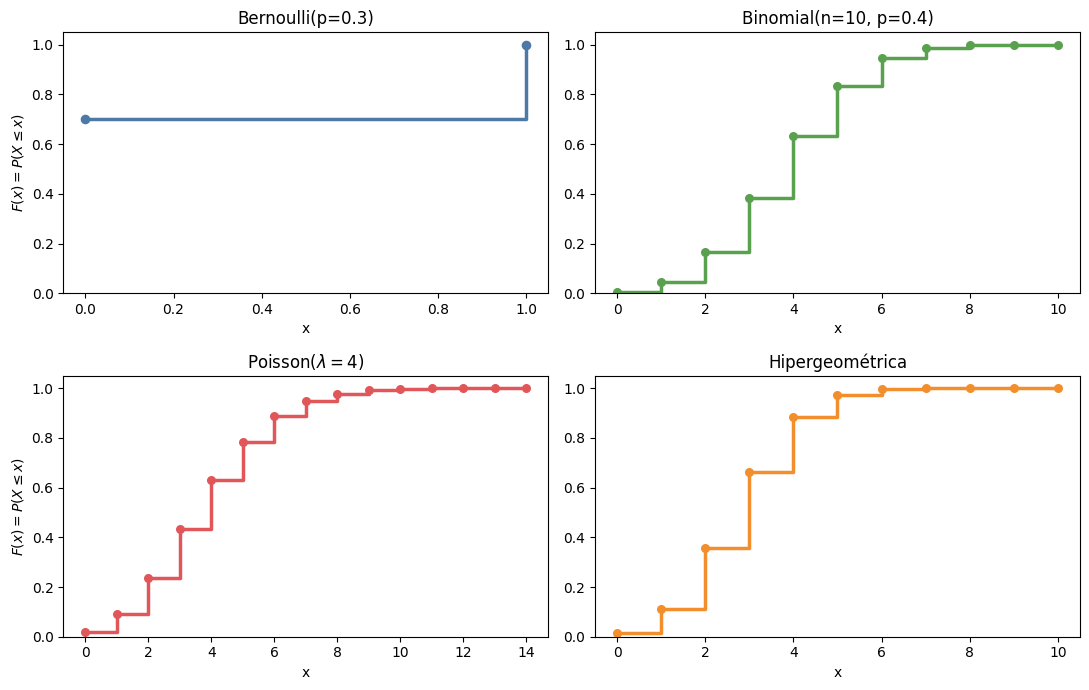

In [ ]:
# ==============================================================================
# Función de distribución acumulada (CDF)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Bernoulli
x = np.array([0, 1])
cdf = stats.bernoulli.cdf(x, p=0.3)
axes[0,0].step(x, cdf, where="post", color="#4E79A7", linewidth=2.5)
axes[0,0].scatter(x, cdf, color="#4E79A7", s=35)
axes[0,0].set_title("Bernoulli(p=0.3)")
axes[0,0].set_ylabel(r"$F(x)=P(X\leq x)$")

# Binomial
x = np.arange(0, 11)
cdf = stats.binom.cdf(x, n=10, p=0.4)
axes[0,1].step(x, cdf, where="post", color="#59A14F", linewidth=2.5)
axes[0,1].scatter(x, cdf, color="#59A14F", s=30)
axes[0,1].set_title("Binomial(n=10, p=0.4)")

# Poisson
x = np.arange(0, 15)
cdf = stats.poisson.cdf(x, mu=4)
axes[1,0].step(x, cdf, where="post", color="#E15759", linewidth=2.5)
axes[1,0].scatter(x, cdf, color="#E15759", s=30)
axes[1,0].set_title(r"Poisson($\lambda=4$)")
axes[1,0].set_ylabel(r"$F(x)=P(X\leq x)$")

# Hipergeométrica
N = 40
K = 12
n = 10
x = np.arange(max(0, n-(N-K)), min(n, K)+1)
cdf = stats.hypergeom.cdf(x, M=N, n=K, N=n)
axes[1,1].step(x, cdf, where="post", color="#F28E2B", linewidth=2.5)
axes[1,1].scatter(x, cdf, color="#F28E2B", s=30)
axes[1,1].set_title("Hipergeométrica")

for ax in axes.flat:
    ax.set_xlabel("x")
    ax.set_ylim(0, 1.05)
    ax.grid(False)

plt.tight_layout()
plt.show()

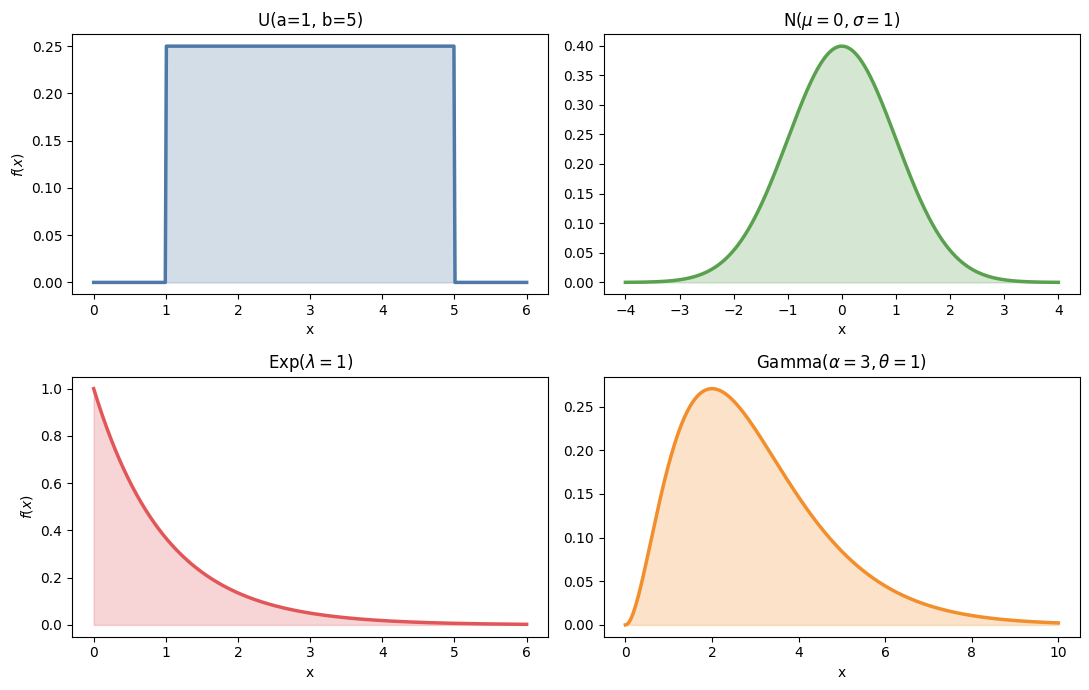

In [ ]:
# ==============================================================================
# Función de densidad (PDF)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Uniforme
x = np.linspace(0, 6, 400)
pdf = stats.uniform.pdf(x, loc=1, scale=4)
axes[0,0].plot(x, pdf, color="#4E79A7", linewidth=2.5)
axes[0,0].fill_between(x, pdf, color="#4E79A7", alpha=0.25)
axes[0,0].set_title("U(a=1, b=5)")
axes[0,0].set_ylabel(r"$f(x)$")

# Normal
x = np.linspace(-4, 4, 400)
pdf = stats.norm.pdf(x, loc=0, scale=1)
axes[0,1].plot(x, pdf, color="#59A14F", linewidth=2.5)
axes[0,1].fill_between(x, pdf, color="#59A14F", alpha=0.25)
axes[0,1].set_title(r"N($\mu=0,\sigma=1$)")

# Exponencial
x = np.linspace(0, 6, 400)
pdf = stats.expon.pdf(x, scale=1)
axes[1,0].plot(x, pdf, color="#E15759", linewidth=2.5)
axes[1,0].fill_between(x, pdf, color="#E15759", alpha=0.25)
axes[1,0].set_title(r"Exp($\lambda=1$)")
axes[1,0].set_ylabel(r"$f(x)$")

# Gamma
x = np.linspace(0, 10, 400)
pdf = stats.gamma.pdf(x, a=3, scale=1)
axes[1,1].plot(x, pdf, color="#F28E2B", linewidth=2.5)
axes[1,1].fill_between(x, pdf, color="#F28E2B", alpha=0.25)
axes[1,1].set_title(r"Gamma($\alpha=3,\theta=1$)")

for ax in axes.flat:
    ax.set_xlabel("x")
    ax.grid(False)

plt.tight_layout()
plt.show()

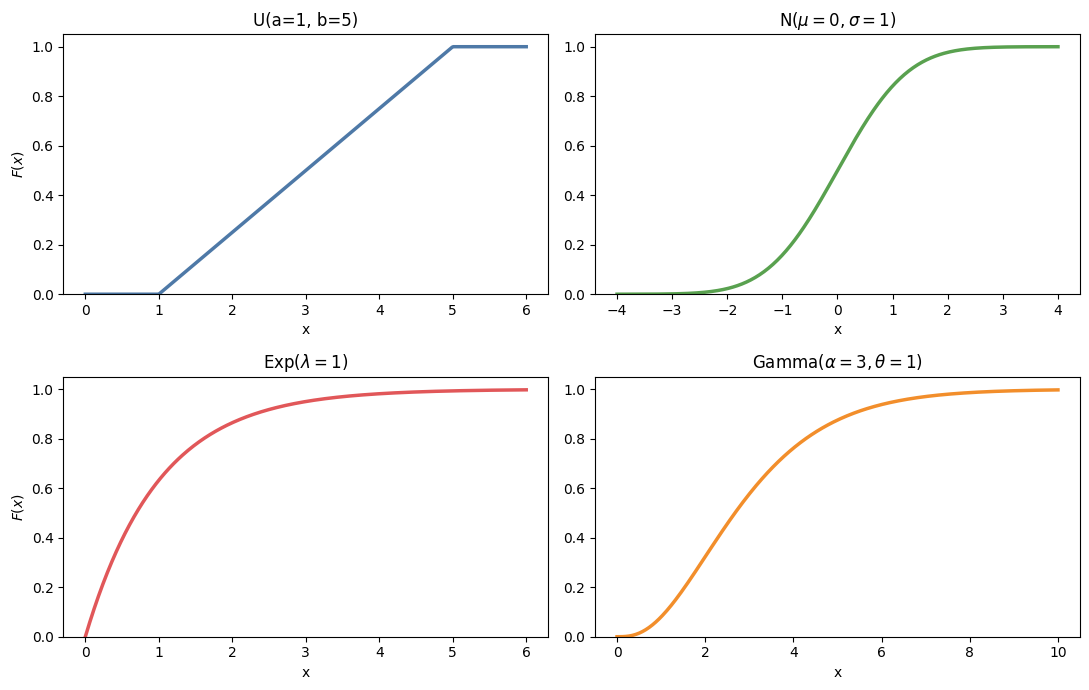

In [ ]:
# ==============================================================================
# Función de distribución acumulada (CDF)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Uniforme
x = np.linspace(0, 6, 400)
cdf = stats.uniform.cdf(x, loc=1, scale=4)
axes[0,0].plot(x, cdf, color="#4E79A7", linewidth=2.5)
axes[0,0].set_title("U(a=1, b=5)")
axes[0,0].set_ylabel(r"$F(x)$")

# Normal
x = np.linspace(-4, 4, 400)
cdf = stats.norm.cdf(x, loc=0, scale=1)
axes[0,1].plot(x, cdf, color="#59A14F", linewidth=2.5)
axes[0,1].set_title(r"N($\mu=0,\sigma=1$)")

# Exponencial
x = np.linspace(0, 6, 400)
cdf = stats.expon.cdf(x, scale=1)
axes[1,0].plot(x, cdf, color="#E15759", linewidth=2.5)
axes[1,0].set_title(r"Exp($\lambda=1$)")
axes[1,0].set_ylabel(r"$F(x)$")

# Gamma
x = np.linspace(0, 10, 400)
cdf = stats.gamma.cdf(x, a=3, scale=1)
axes[1,1].plot(x, cdf, color="#F28E2B", linewidth=2.5)
axes[1,1].set_title(r"Gamma($\alpha=3,\theta=1$)")

for ax in axes.flat:
    ax.set_xlabel("x")
    ax.set_ylim(0, 1.05)
    ax.grid(False)

plt.tight_layout()
plt.show()

## **3. Distribuciones muestrales**

Una **distribución muestral** describe cómo varía un estadístico (por ejemplo, la media muestral $\bar{x}$) de una muestra a otra. El resultado más importante es el **Teorema del Límite Central (TLC)**:

> Si se toman muestras de tamaño $n$ suficientemente grande de *cualquier* población (con media $\mu$ y varianza $\sigma^2$ finitas), la distribución de $\bar{x}$ se aproxima a una **Normal** con:
> $$\mu_{\bar{x}} = \mu \qquad \sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$$

Vamos a comprobarlo partiendo de una población **muy asimétrica** (exponencial), que no se parece en nada a una normal:


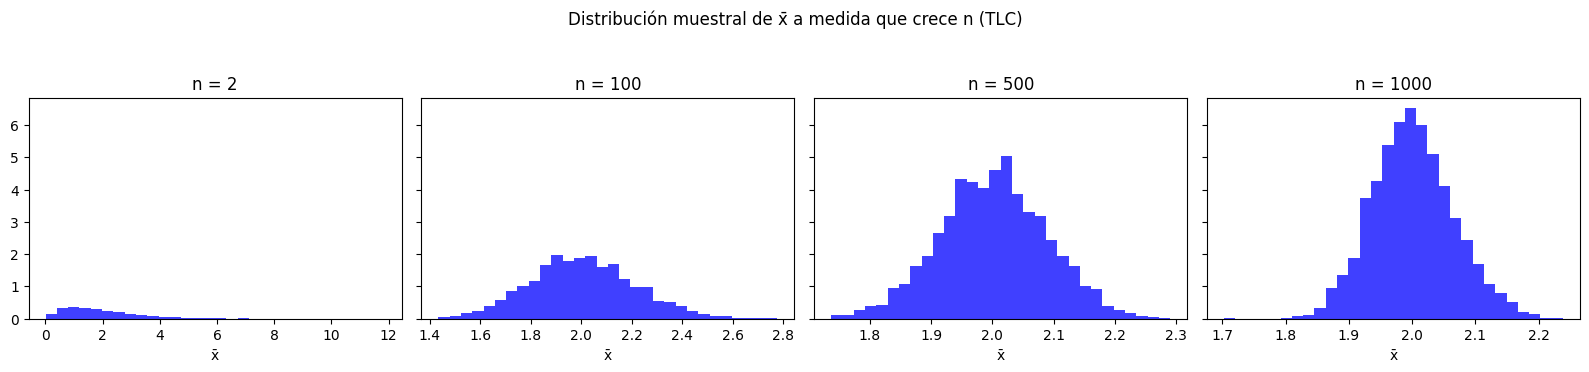

In [ ]:
# TLC ==========================================================================
poblacion = stats.expon(scale=2)  # población muy sesgada
tamanos_muestra = [2, 100, 500, 1000]
n_muestras = 3000

fig, axes = plt.subplots(1, len(tamanos_muestra), figsize=(16, 3.5), sharey=True)

for ax, n in zip(axes, tamanos_muestra):
    medias = poblacion.rvs(size=(n_muestras, n)).mean(axis=1)
    ax.hist(medias, bins=30, color="blue", alpha=0.75, density=True)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("x̄")

fig.suptitle("Distribución muestral de x̄ a medida que crece n (TLC)", y=1.05)
plt.tight_layout()
plt.show()


## **4. Estimación**

### **4.1 Estimación puntual**

Un **estimador puntual** es un único valor calculado a partir de una muestra que se usa para aproximar un parámetro poblacional desconocido.

### **4.2 Intervalos de confianza**



Un **intervalo de confianza** (IC) da un rango de valores plausibles para el parámetro, con un nivel de confianza $1-\alpha$.


Calculemos el IC del 95% para la media de las facturas anteriores:


## **5. Pruebas de hipótesis**

Una **prueba de hipótesis** es un procedimiento para decidir, con base en una muestra, si hay evidencia suficiente para rechazar una afirmación ($H_0$) sobre un parámetro poblacional.

**Tipos de error**

| | $H_0$ verdadera | $H_0$ falsa |
|---|---|---|
| **Rechazar $H_0$** | Error Tipo I ($\alpha$) | Decisión correcta |
| **No rechazar $H_0$** | Decisión correcta | Error Tipo II ($\beta$) |


> **Ejemplo 15:**

> El MTC afirma que el tiempo promedio de espera de los usuarios en los paraderos del sistema de transporte público de Huancayo es de 12 minutos. Indecopi sospecha que, debido a la reducción reciente en la frecuencia de las unidades, el tiempo de espera real es mayor al reportado por el Ministerio. Para verificar ello, Indecopi toma una muestra aleatoria de 40 usuarios en distintos paraderos y horarios, registrando su tiempo de espera. Se obtiene un tiempo promedio de 13.5 minutos, con una desviación estándar de 4 minutos. Utilizando $\alpha=5\%$, ?`existe evidencia suficiente para afirmar que el tiempo de espera promedio real es mayor al que reporta el MTC?


Como se trata de una variable continua (tiempo, en minutos) y no se conoce $\sigma$ poblacional, esto corresponde a una **prueba $t$ para la media**, de cola derecha:

$$H_0: \mu = 12 \qquad H_1: \mu > 12$$

In [ ]:
# Datos del problema
mu0 = 12          # valor hipotético del Ministerio
x_barra = 13.5    # media muestral
s = 4             # desviación estándar muestral
n = 40            # tamaño de muestra
alpha = 0.05

# Estadístico de prueba
t_calculado = (x_barra - mu0) / (s / np.sqrt(n))
gl = n - 1

# Valor crítico y p-valor (cola derecha)
t_critico = stats.t.ppf(1 - alpha, df=gl)
p_valor = 1 - stats.t.cdf(t_calculado, df=gl)

print(f"Estadístico t calculado: {t_calculado:.3f}")
print(f"t crítico (gl={gl}, α={alpha}): {t_critico:.3f}")
print(f"p-valor: {p_valor:.4f}")

if t_calculado > t_critico:
    print("\n➡️ Se rechaza H0: hay evidencia de que el tiempo de espera promedio es mayor a 12 min.")
else:
    print("\n➡️ No se rechaza H0: no hay evidencia suficiente de que el tiempo promedio sea mayor a 12 min.")

Estadístico t calculado: 2.372
t crítico (gl=39, α=0.05): 1.685
p-valor: 0.0114

➡️ Se rechaza H0: hay evidencia de que el tiempo de espera promedio es mayor a 12 min.


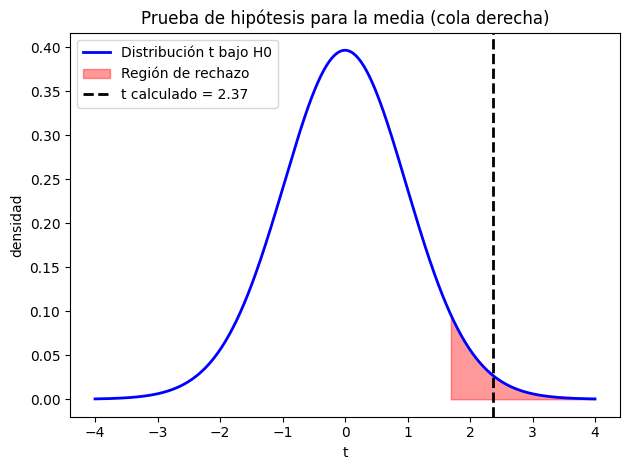

In [ ]:
# Visualización de la región de rechazo
x = np.linspace(-4, 4, 400)
y = stats.t.pdf(x, df=gl)

plt.plot(x, y, color="blue", lw=2, label="Distribución t bajo H0")
plt.fill_between(x, y, where=(x >= t_critico), color="red", alpha=0.4,
                  label=f"Región de rechazo")
plt.axvline(t_calculado, color="black", linestyle="--", lw=2, label=f"t calculado = {t_calculado:.2f}")
plt.title("Prueba de hipótesis para la media (cola derecha)")
plt.xlabel("t"); plt.ylabel("densidad")
plt.legend()
plt.tight_layout()
plt.show()
